<a href="https://colab.research.google.com/github/Sudhar-san24/DataScience-Course/blob/main/FinTech_Customer_Life_Time(LTV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder #for cat data
from sklearn.preprocessing import StandardScaler,MinMaxScaler #for num data
from sklearn.preprocessing import PolynomialFeatures #for target
from sklearn.impute import SimpleImputer #for missing value
from sklearn.compose import ColumnTransformer #for combing
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [6]:
df=pd.read_csv('/content/digital_wallet_ltv_dataset.csv')
df.head()

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05


In [7]:
df.head()

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  7000 non-null   object 
 1   Age                          7000 non-null   int64  
 2   Location                     7000 non-null   object 
 3   Income_Level                 7000 non-null   object 
 4   Total_Transactions           7000 non-null   int64  
 5   Avg_Transaction_Value        7000 non-null   float64
 6   Max_Transaction_Value        7000 non-null   float64
 7   Min_Transaction_Value        7000 non-null   float64
 8   Total_Spent                  7000 non-null   float64
 9   Active_Days                  7000 non-null   int64  
 10  Last_Transaction_Days_Ago    7000 non-null   int64  
 11  Loyalty_Points_Earned        7000 non-null   int64  
 12  Referral_Count               7000 non-null   int64  
 13  Cashback_Received 

In [9]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Location,0
Income_Level,0
Total_Transactions,0
Avg_Transaction_Value,0
Max_Transaction_Value,0
Min_Transaction_Value,0
Total_Spent,0
Active_Days,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,42.633714,501.221429,9946.831482,30159.596784,2981.549953,5.002022e+06,181.934857,183.847714,2501.545429,24.837000,2496.525032,10.017571,36.528007,5.479000,5.119197e+05
std,15.516036,286.277311,5780.880831,21996.108793,2197.342161,4.390495e+06,105.102598,105.063709,1446.680026,14.560352,1440.651412,6.037067,20.389399,2.860197,4.390551e+05
min,16.000000,1.000000,10.185827,31.857484,4.617966,1.498144e+03,1.000000,1.000000,0.000000,0.000000,0.234349,0.000000,1.019853,1.000000,3.770495e+03
25%,29.000000,252.000000,4907.466790,12224.329366,1233.066226,1.363991e+06,90.000000,93.000000,1254.750000,12.000000,1269.423703,5.000000,19.127302,3.000000,1.482058e+05
50%,43.000000,506.000000,9841.172643,25469.392130,2473.181073,3.756105e+06,182.000000,184.000000,2466.000000,25.000000,2478.943350,10.000000,36.257396,5.000000,3.878180e+05
75%,56.000000,744.000000,14955.048801,44515.414177,4378.759195,7.645508e+06,273.000000,275.000000,3792.250000,37.000000,3749.375251,15.000000,54.068594,8.000000,7.748578e+05
max,69.000000,1000.000000,19996.445086,98809.241533,9917.028823,1.946773e+07,365.000000,365.000000,5000.000000,50.000000,4999.698480,20.000000,71.978946,10.000000,1.956988e+06


In [12]:
df['Income_Level'].value_counts()

,count
Income_Level,
Middle,2391
Low,2311
High,2298


In [13]:
df['Location'].value_counts()

,count
Location,
Urban,2368
Suburban,2320
Rural,2312


In [14]:
df['App_Usage_Frequency'].value_counts()

,count
App_Usage_Frequency,
Daily,2346
Monthly,2329
Weekly,2325


In [15]:
df['Preferred_Payment_Method'].value_counts()

,count
Preferred_Payment_Method,
UPI,1791
Debit Card,1761
Wallet Balance,1736
Credit Card,1712


In [17]:
df=df.drop(['Customer_ID'],axis=1)

In [18]:
Cat_features=df.select_dtypes(include='object')
Cat_features

,Location,Income_Level,App_Usage_Frequency,Preferred_Payment_Method
0,Urban,Low,Monthly,Debit Card
1,Suburban,High,Monthly,UPI
2,Urban,High,Monthly,Debit Card
3,Rural,High,Weekly,Wallet Balance
4,Urban,Middle,Daily,UPI
...,...,...,...,...
6995,Suburban,High,Monthly,Credit Card
6996,Suburban,High,Monthly,Wallet Balance
6997,Urban,Middle,Monthly,UPI
6998,Urban,High,Monthly,Credit Card


In [19]:
Num_features=df.select_dtypes(exclude='object')
Num_features

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,54,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,3,61.568590,1,3.279546e+05
1,67,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,17,60.392889,8,1.437053e+06
2,44,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,11,45.305579,4,2.419387e+05
3,30,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,6,22.030191,1,1.284599e+05
4,58,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,18,20.634723,5,9.569514e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,68,340,162.703503,605.997495,80.352666,5.531919e+04,78,20,521,32,654.218655,14,3.351374,3,1.244681e+04
6996,62,647,1575.707877,4702.522747,359.511332,1.019483e+06,271,252,2972,40,3574.857418,13,19.735330,3,1.131049e+05
6997,16,481,14429.355178,17207.737631,1510.598329,6.940520e+06,225,348,2423,8,2899.068571,12,45.036932,2,7.002484e+05
6998,32,574,8005.027184,33203.795716,1976.326124,4.594886e+06,121,50,634,31,2432.363200,11,44.145749,1,4.636404e+05


#Univariate

In [20]:
Num_features.columns

Index(['Age', 'Total_Transactions', 'Avg_Transaction_Value',
       'Max_Transaction_Value', 'Min_Transaction_Value', 'Total_Spent',
       'Active_Days', 'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned',
       'Referral_Count', 'Cashback_Received', 'Support_Tickets_Raised',
       'Issue_Resolution_Time', 'Customer_Satisfaction_Score', 'LTV'],
      dtype='object')

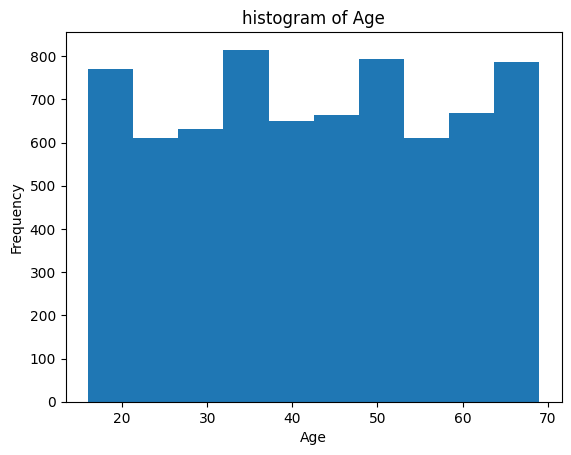

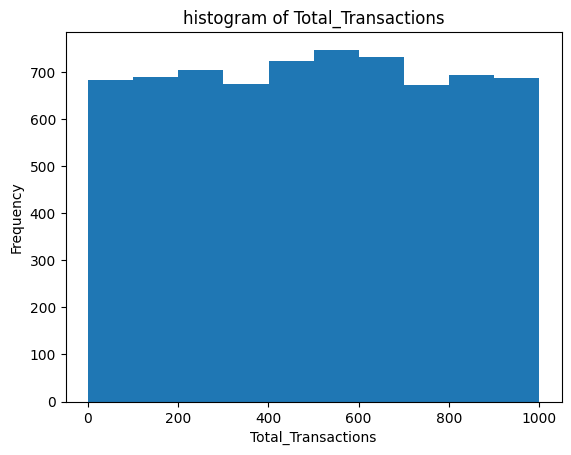

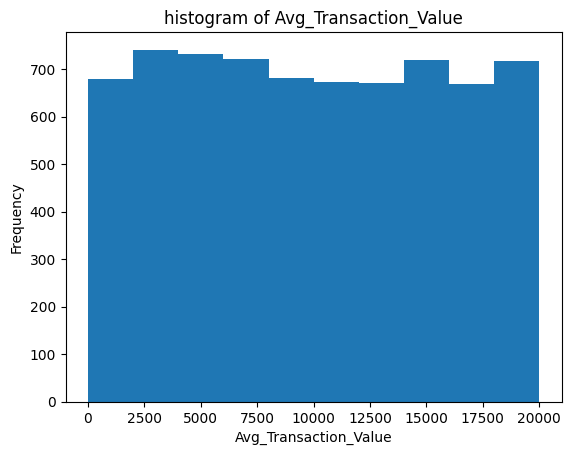

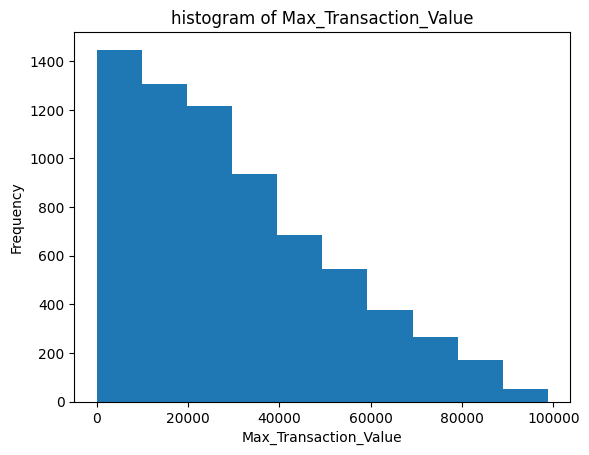

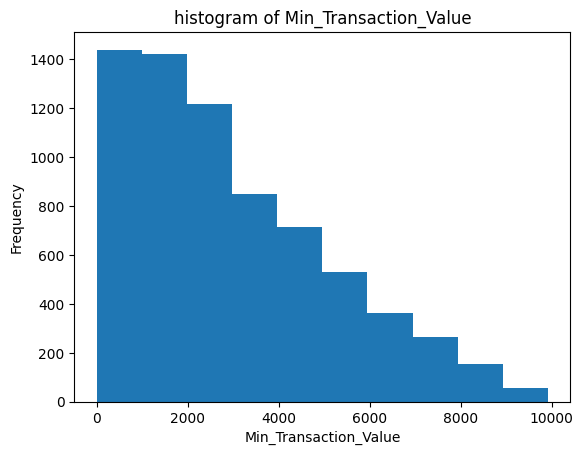

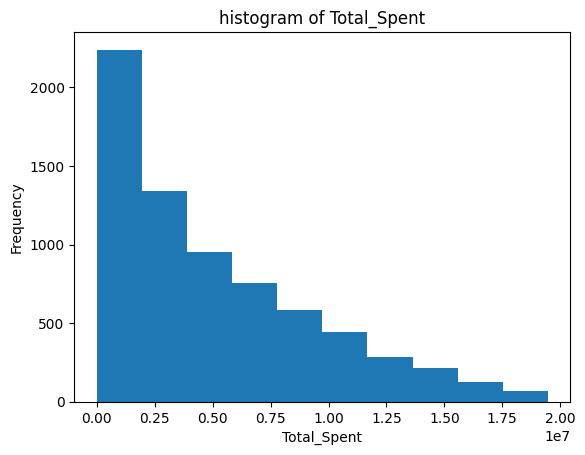

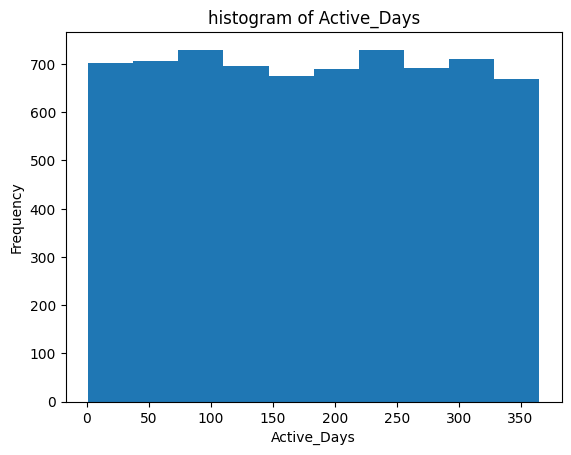

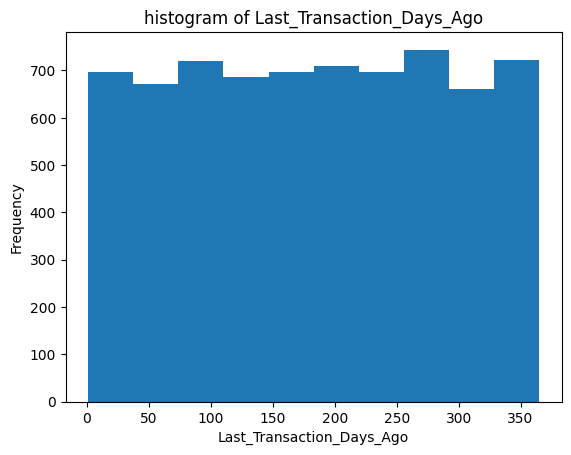

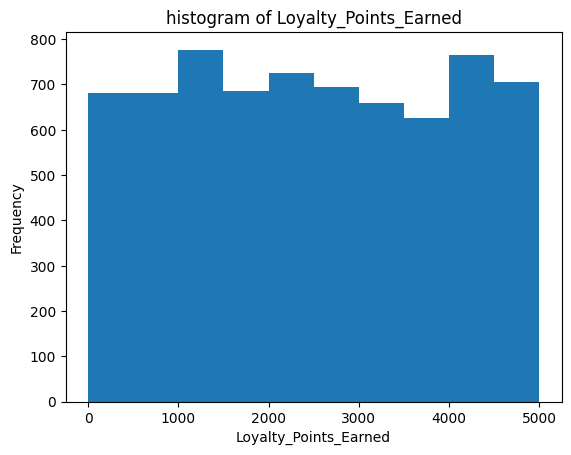

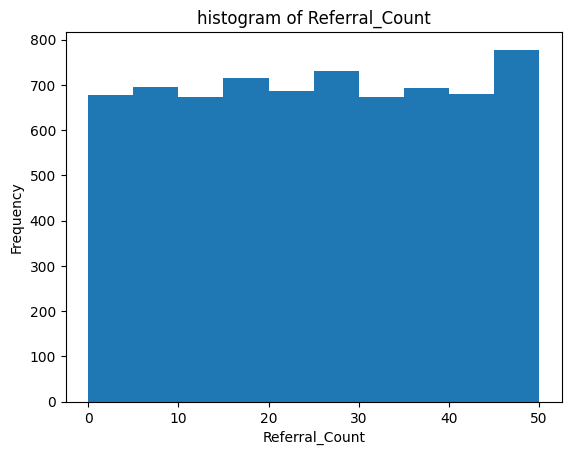

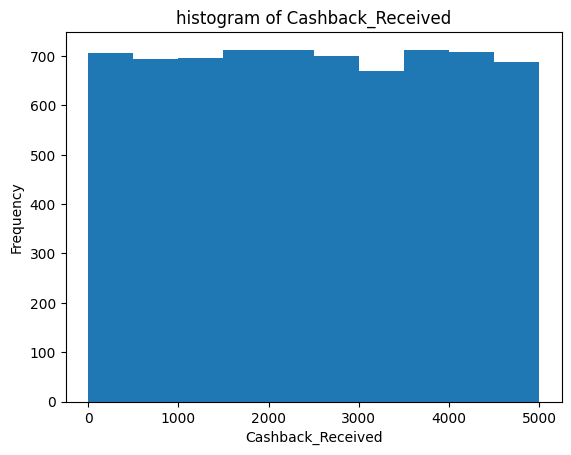

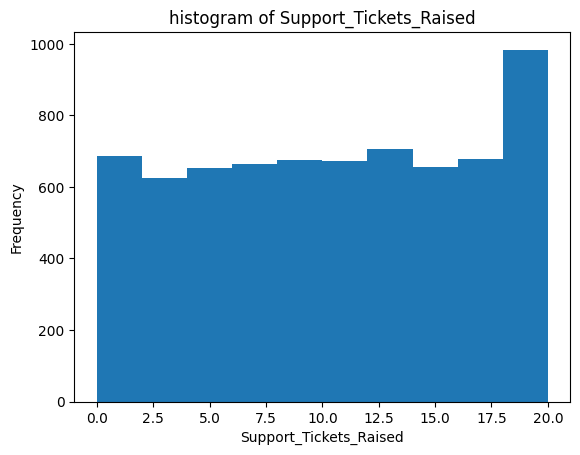

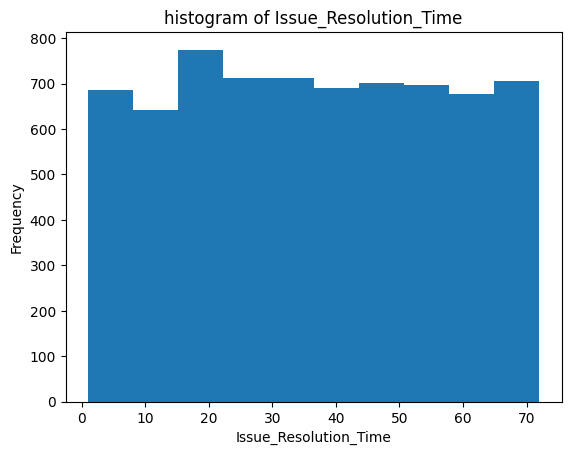

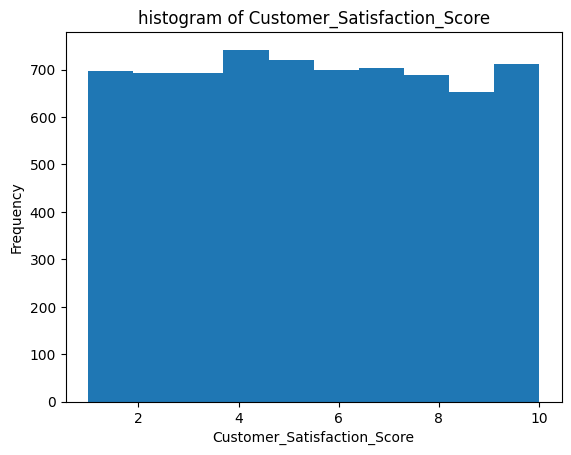

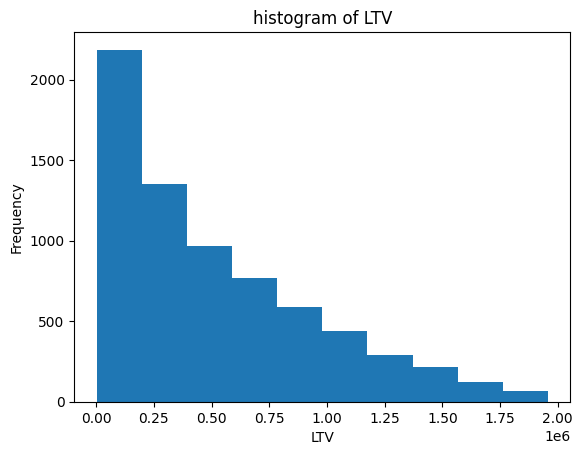

In [22]:
#Histogram
for i in Num_features.columns:
  plt.hist(df[i],bins=10)
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.title(f'histogram of {i}')
  plt.show()

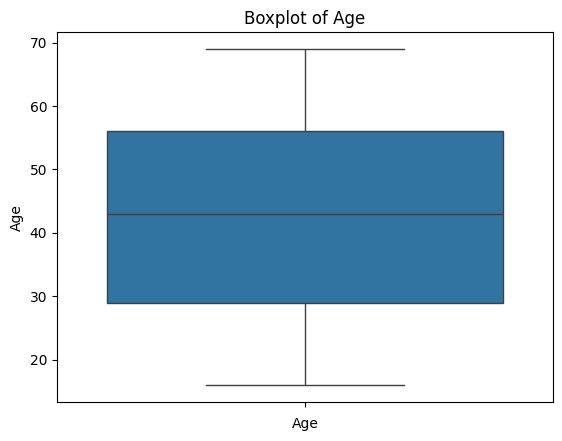

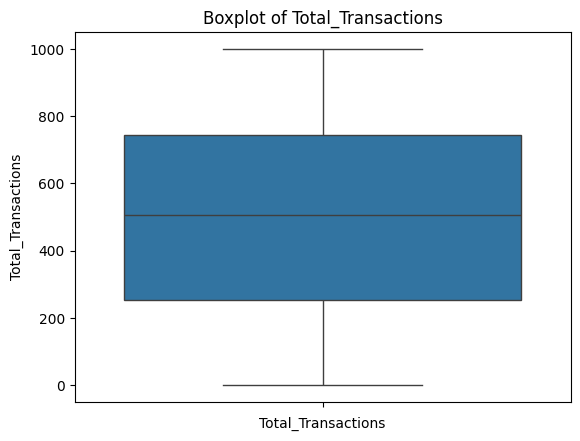

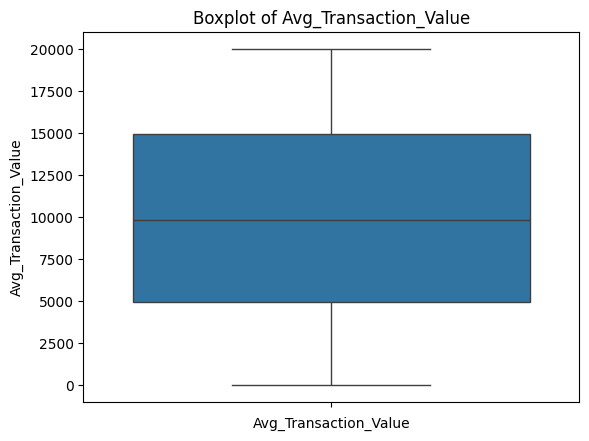

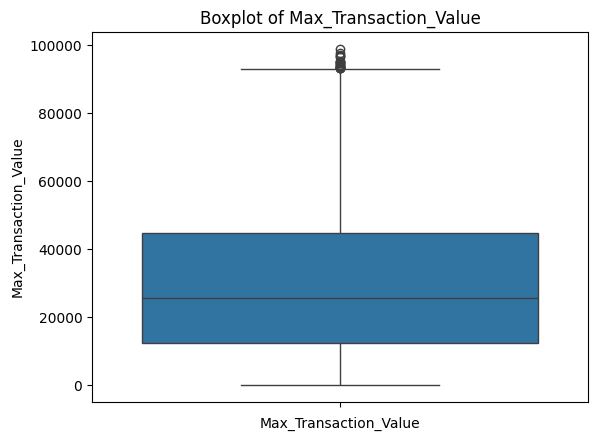

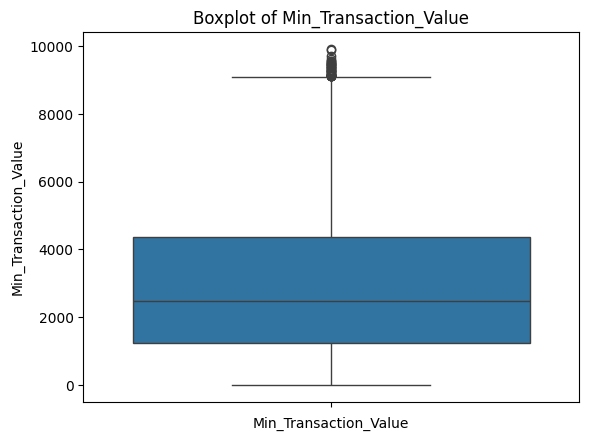

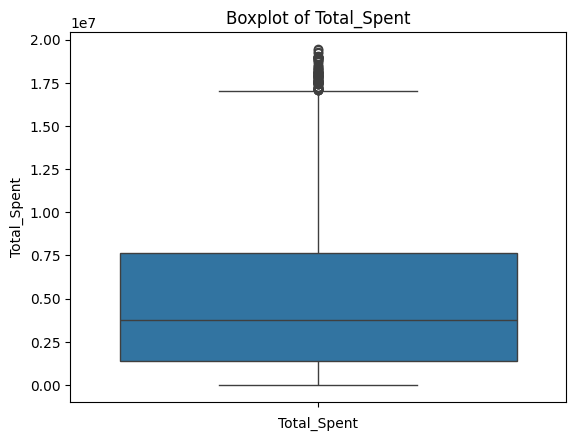

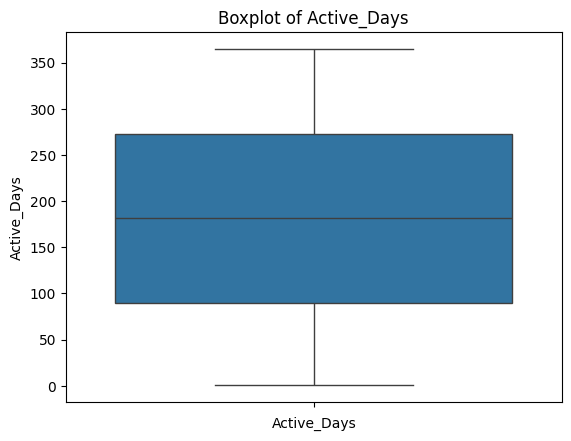

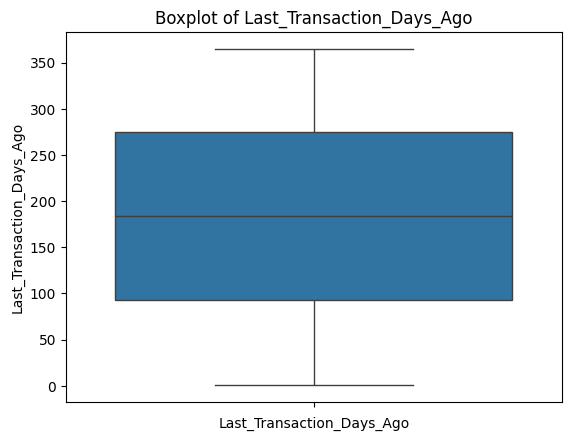

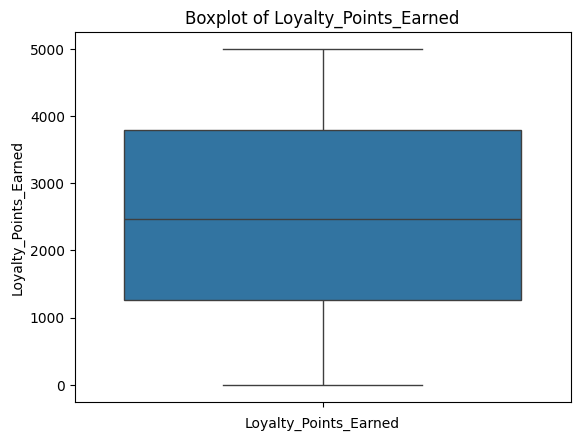

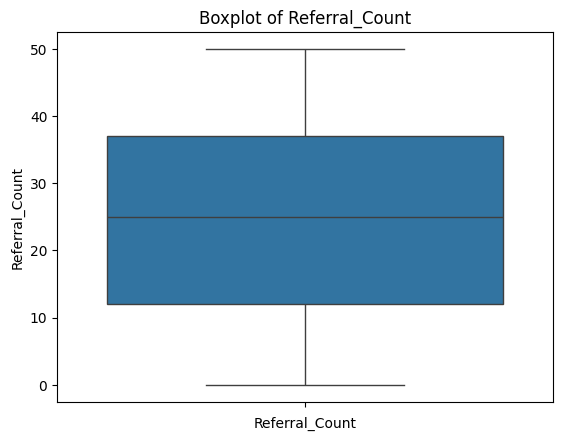

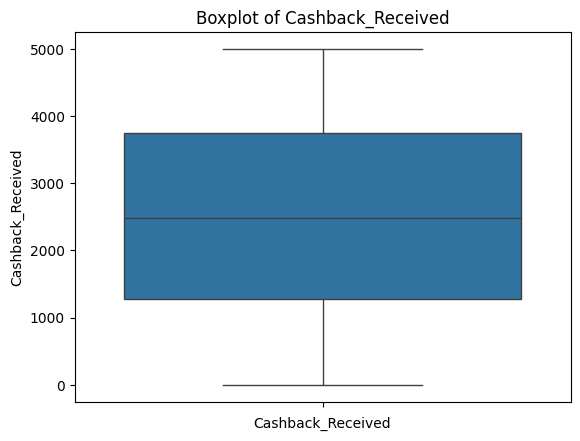

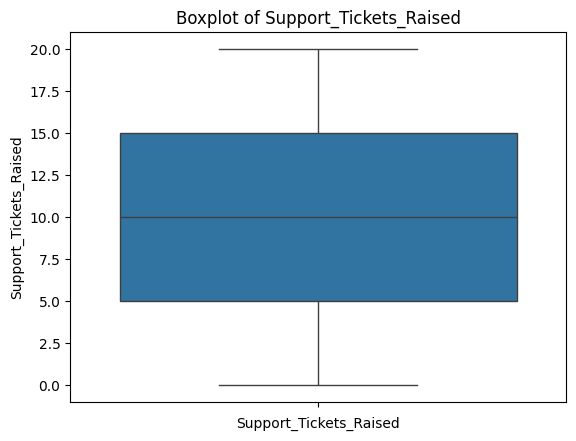

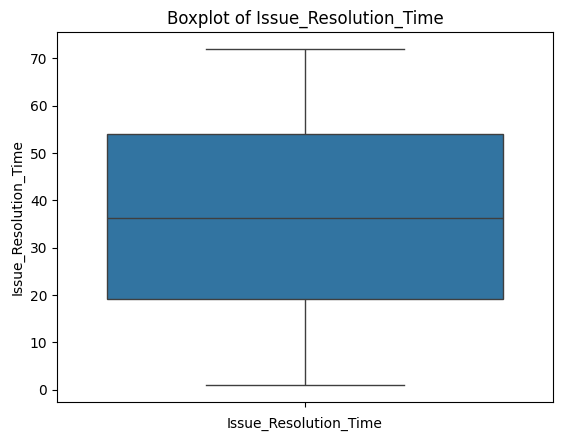

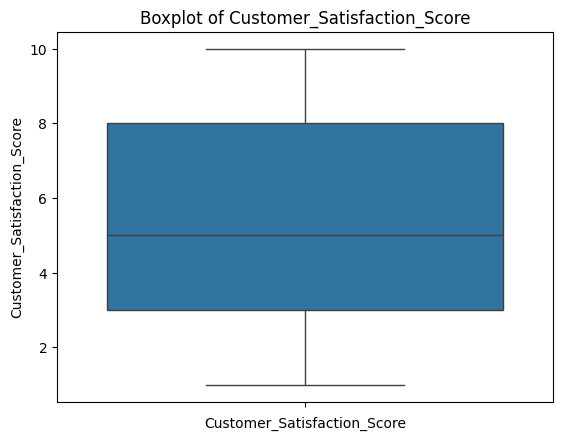

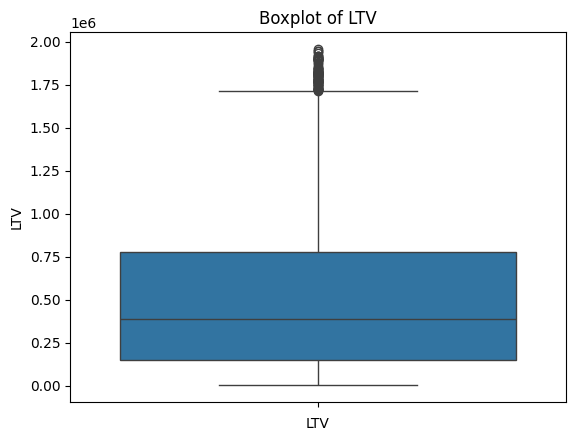

In [23]:
for i in Num_features.columns:
  sns.boxplot(df[i])
  plt.xlabel(i)
  plt.title(f'Boxplot of {i}')
  plt.show()


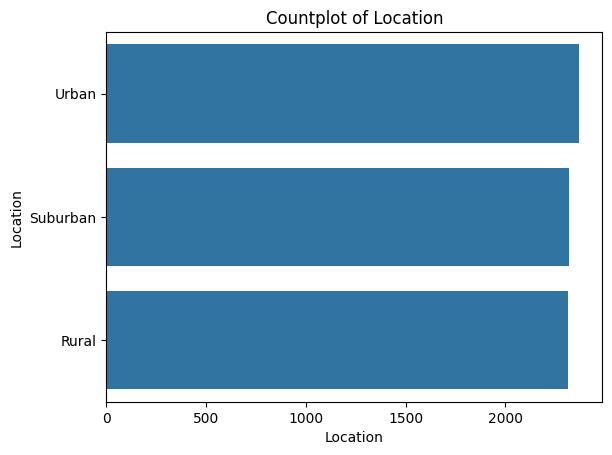

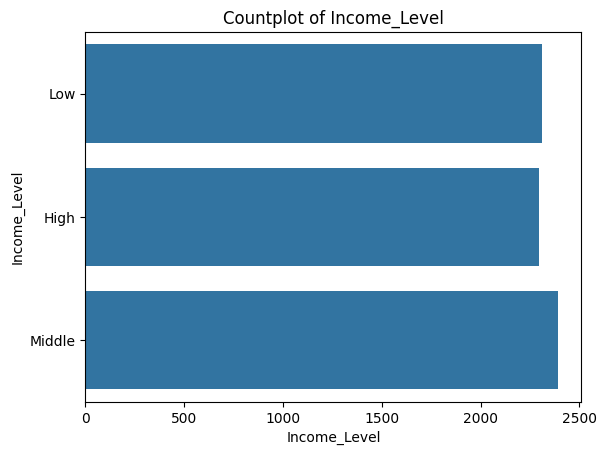

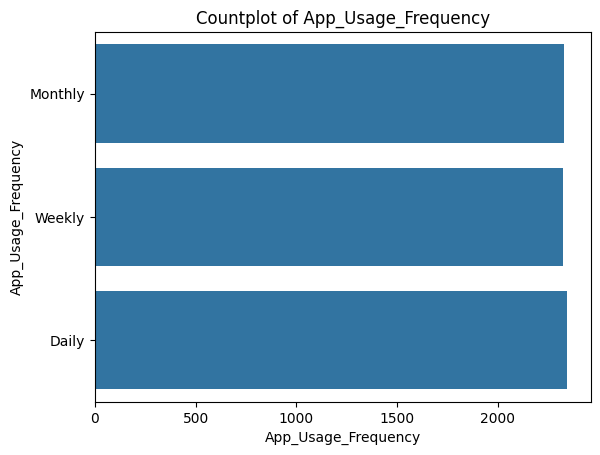

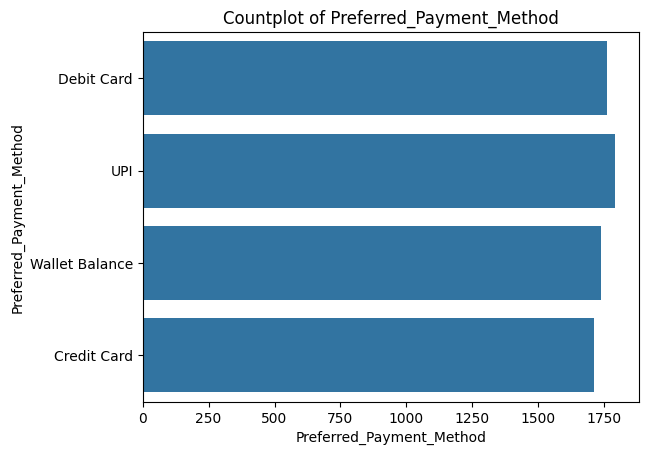

In [24]:
for i in Cat_features.columns:
  sns.countplot(df[i])
  plt.xlabel(i)
  plt.title(f'Countplot of {i}')
  plt.show()

Bivariate analysis

In [25]:
Num_features.corr()

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
Age,1.000000,0.023290,-0.005309,-0.017689,-0.000485,0.007751,0.001923,0.018288,0.008054,-0.025779,-0.001426,0.012947,-0.014170,-0.011635,0.007645
Total_Transactions,0.023290,1.000000,0.009945,0.016583,0.015383,0.650862,-0.008554,-0.012050,0.005674,-0.017543,0.006864,-0.030529,0.013875,0.006405,0.650863
Avg_Transaction_Value,-0.005309,0.009945,1.000000,0.798205,0.795665,0.664973,-0.019275,0.004488,-0.001632,-0.020102,-0.026621,-0.006030,-0.015604,-0.000187,0.664929
Max_Transaction_Value,-0.017689,0.016583,0.798205,1.000000,0.632216,0.540476,-0.021632,-0.001394,-0.007396,-0.015600,-0.035452,-0.002343,-0.010027,-0.002484,0.540410
Min_Transaction_Value,-0.000485,0.015383,0.795665,0.632216,1.000000,0.537285,-0.020886,0.004911,0.003093,-0.011633,-0.006555,-0.007616,-0.016587,0.004337,0.537299
Total_Spent,0.007751,0.650862,0.664973,0.540476,0.537285,1.000000,-0.016684,-0.003326,-0.002867,-0.026780,-0.009613,-0.029662,-0.001129,0.008218,0.999949
Active_Days,0.001923,-0.008554,-0.019275,-0.021632,-0.020886,-0.016684,1.000000,0.003661,-0.013860,0.000073,-0.011079,-0.013073,0.002390,0.002919,-0.016738
Last_Transaction_Days_Ago,0.018288,-0.012050,0.004488,-0.001394,0.004911,-0.003326,0.003661,1.000000,0.005825,0.003977,0.023388,0.008806,0.011490,-0.010577,-0.003382
Loyalty_Points_Earned,0.008054,0.005674,-0.001632,-0.007396,0.003093,-0.002867,-0.013860,0.005825,1.000000,0.015958,-0.016326,-0.010676,-0.008750,0.007581,0.003852
Referral_Count,-0.025779,-0.017543,-0.020102,-0.015600,-0.011633,-0.026780,0.000073,0.003977,0.015958,1.000000,0.013653,0.005219,-0.010850,0.009979,-0.023315


In [26]:
Num_features.corr()['LTV']

,LTV
Age,0.007645
Total_Transactions,0.650863
Avg_Transaction_Value,0.664929
Max_Transaction_Value,0.540410
Min_Transaction_Value,0.537299
Total_Spent,0.999949
Active_Days,-0.016738
Last_Transaction_Days_Ago,-0.003382
Loyalty_Points_Earned,0.003852
Referral_Count,-0.023315


In [27]:
Num_features.corr(method='spearman')['LTV']

,LTV
Age,0.012016
Total_Transactions,0.661623
Avg_Transaction_Value,0.681079
Max_Transaction_Value,0.598789
Min_Transaction_Value,0.597238
Total_Spent,0.999843
Active_Days,-0.011859
Last_Transaction_Days_Ago,-0.004928
Loyalty_Points_Earned,0.015204
Referral_Count,-0.026073


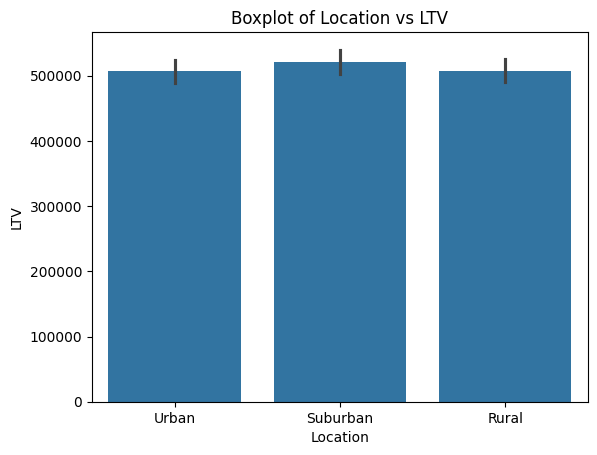

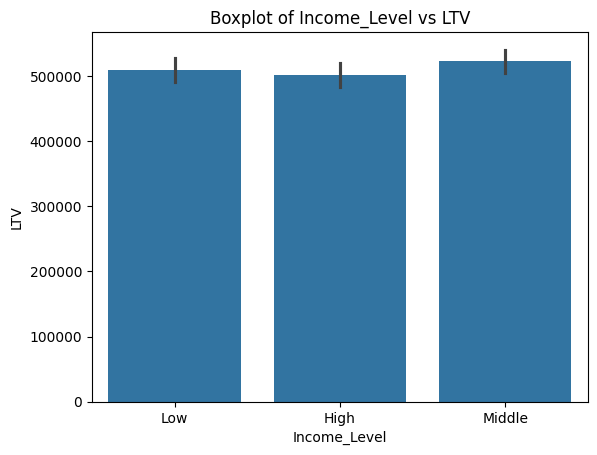

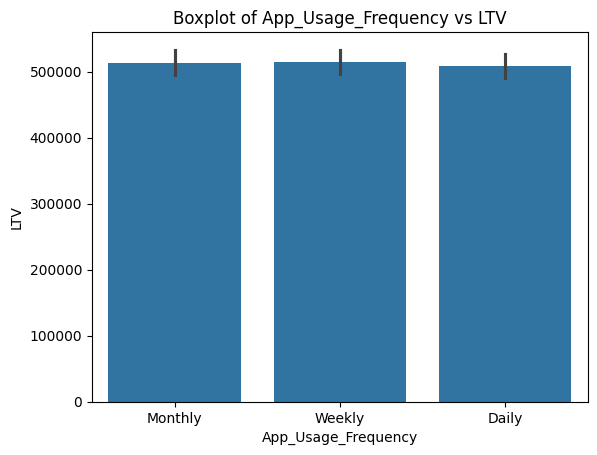

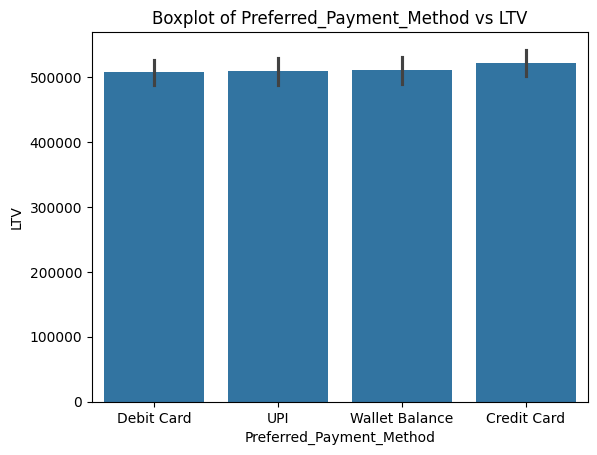

In [30]:
for i in Cat_features.columns:
  sns.barplot(data=df,x=i,y='LTV')
  plt.xlabel(i)
  plt.ylabel('LTV')
  plt.title(f'Boxplot of {i} vs LTV')
  plt.show()

In [32]:
df.groupby('Preferred_Payment_Method')['LTV'].mean().sort_values(ascending=False)

,LTV
Preferred_Payment_Method,
Credit Card,521823.687294
Wallet Balance,509799.477330
UPI,508490.165174
Debit Card,507869.441661


In [33]:
df['Preferred_Payment_Method'].value_counts()

,count
Preferred_Payment_Method,
UPI,1791
Debit Card,1761
Wallet Balance,1736
Credit Card,1712


In [34]:
Num_features=Num_features.drop(['LTV'],axis=1)
Num_features

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score
0,54,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,3,61.568590,1
1,67,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,17,60.392889,8
2,44,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,11,45.305579,4
3,30,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,6,22.030191,1
4,58,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,18,20.634723,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,68,340,162.703503,605.997495,80.352666,5.531919e+04,78,20,521,32,654.218655,14,3.351374,3
6996,62,647,1575.707877,4702.522747,359.511332,1.019483e+06,271,252,2972,40,3574.857418,13,19.735330,3
6997,16,481,14429.355178,17207.737631,1510.598329,6.940520e+06,225,348,2423,8,2899.068571,12,45.036932,2
6998,32,574,8005.027184,33203.795716,1976.326124,4.594886e+06,121,50,634,31,2432.363200,11,44.145749,1


In [36]:
Numerical_transformer_mean_StdScalar=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

In [37]:
Numerical_transformer_mean_MinMax=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',MinMaxScaler())
])

In [39]:
Categorial_transformer_onehot=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('Onehot_encoder',OneHotEncoder(drop='first'))
])

In [42]:
df['App_Usage_Frequency'].unique()

array(['Monthly', 'Weekly', 'Daily'], dtype=object)

In [40]:
Categorial_transformer_Ordinal=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('Ordinal_encoder',OrdinalEncoder(categories=[['Urban', 'Suburban', 'Rural'],
                                                  ['Monthly', 'Weekly', 'Daily'],
                                                  ]))
])

TypeError: OrdinalEncoder.__init__() got an unexpected keyword argument 'drop'

In [ ]:
Transformer=ColumnTransformer(transformers=[
    ('num_mean_Std',Numerical_transformer_mean_StdScalar,Num_features.columns),
    (OrdinalEncoder)